Name: Sakshi Jadhav  
Roll No.: EN23107043   
Department: AIDS-A  
Subject: AI-PD  

<h3>ASSIGNMENT NO-06</h3>

Dataset: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

In [1]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
df = pd.read_csv("spam.csv", encoding="latin-1")
print(df.columns)

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')


In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

In [5]:
df.columns = ["label", "text"]

In [6]:
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
df["label"] = df["label"].map({"ham":0, "spam":1})

In [8]:
print(df.shape)
print(df["label"].value_counts())

(5572, 2)
label
0    4825
1     747
Name: count, dtype: int64


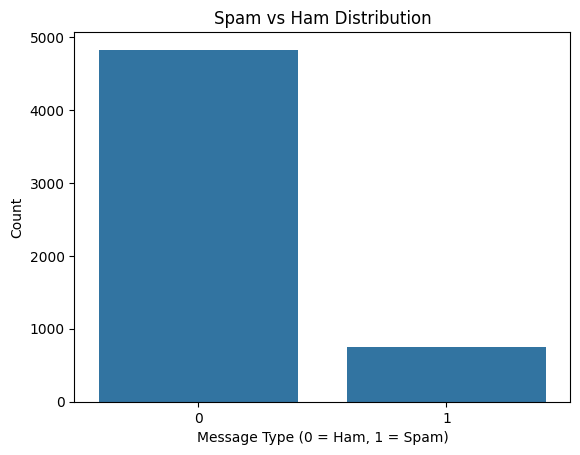

In [9]:
plt.figure()
sns.countplot(x=df["label"])
plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type (0 = Ham, 1 = Spam)")
plt.ylabel("Count")
plt.show()

In [10]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    return text

In [11]:
df["clean_text"] = df["text"].apply(clean_text)

In [12]:
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(df["clean_text"])
y = df["label"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [14]:
nb = MultinomialNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)
print("Naive Bayes\n")

print("Accuracy:", accuracy_score(y_test, pred_nb))
print("Precision:", precision_score(y_test, pred_nb))
print("Recall:", recall_score(y_test, pred_nb))
print("F1:", f1_score(y_test, pred_nb))

Naive Bayes

Accuracy: 0.967713004484305
Precision: 1.0
Recall: 0.76
F1: 0.8636363636363636


In [15]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
print("Logistic Regression\n")

print("Accuracy:", accuracy_score(y_test, pred_lr))
print("Precision:", precision_score(y_test, pred_lr))
print("Recall:", recall_score(y_test, pred_lr))
print("F1:", f1_score(y_test, pred_lr))

Logistic Regression

Accuracy: 0.9533632286995516
Precision: 0.9711538461538461
Recall: 0.6733333333333333
F1: 0.7952755905511811


In [16]:
svm = SVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)
print("SVM\n")

print("Accuracy:", accuracy_score(y_test, pred_svm))
print("Precision:", precision_score(y_test, pred_svm))
print("Recall:", recall_score(y_test, pred_svm))
print("F1:", f1_score(y_test, pred_svm))

SVM

Accuracy: 0.9704035874439462
Precision: 0.9915966386554622
Recall: 0.7866666666666666
F1: 0.8773234200743495


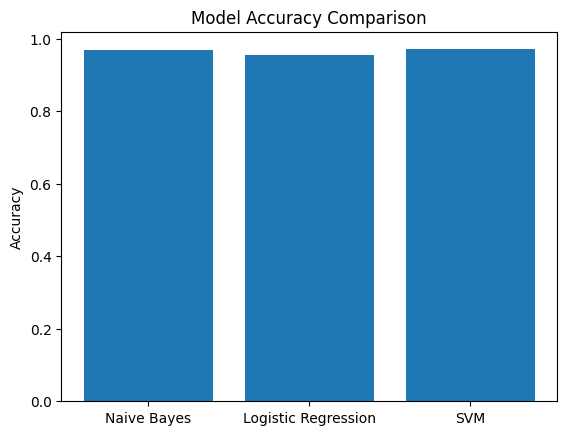

In [17]:
results = {
    "Naive Bayes": accuracy_score(y_test, pred_nb),
    "Logistic Regression": accuracy_score(y_test, pred_lr),
    "SVM": accuracy_score(y_test, pred_svm)
}

plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

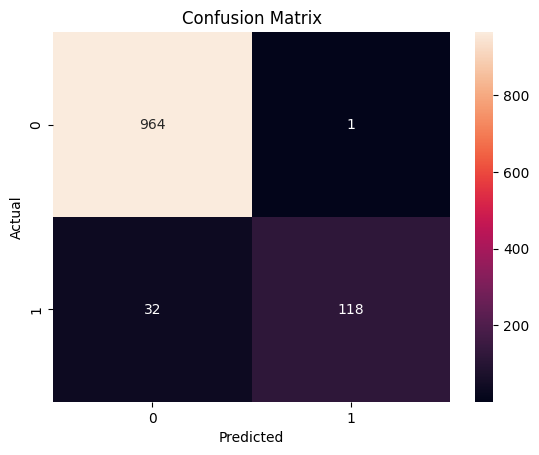

In [18]:
cm = confusion_matrix(y_test, pred_svm)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [21]:
user_msg = input("Enter SMS or Email: ")
msg = clean_text(user_msg)
msg_vec = vectorizer.transform([msg])
prediction = nb.predict(msg_vec)
if prediction[0] == 1:
    print("Prediction: Spam Message")
else:
    print("Prediction: Ham (Not Spam)")

Enter SMS or Email:  WIN a free iPhone now!!! Click here to claim your prize


Prediction: Spam Message


In [22]:
user_msg = input("Enter SMS or Email: ")
msg = clean_text(user_msg)
msg_vec = vectorizer.transform([msg])
prediction = nb.predict(msg_vec)
if prediction[0] == 1:
    print("Prediction: Spam Message")
else:
    print("Prediction: Ham (Not Spam)")

Enter SMS or Email:  Did you complete your assignment?


Prediction: Ham (Not Spam)
